<a href="https://colab.research.google.com/github/shantanukhatri5-117/hybrid-qaoa-spacecraft/blob/main/Copy_of_final_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CHALLENGING FAULT DETECTION SYSTEM - REALISTIC DATA

[1/6] Generating challenging telemetry data...
Generating 4000 normal samples...
Generating 1000 challenging faulty samples...

✓ Dataset generated:
  - Total samples: 5000
  - Normal (0): 4000 (80.0%)
  - Faulty (1): 1000 (20.0%)
  - Fault ratio: 20.0%

[2/6] Normalizing and splitting data...
✓ Training: 4000 samples
  Test: 1000 samples
  Train fault ratio: 20.0%
  Test fault ratio: 20.0%

[3/6] Building model with strong regularization...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 20, 64)         │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,689 (57.38 KB)

 Trainable params: 14,689 (57.38 KB)

 Non-trainable params: 0 (0.00 B)


[4/6] Training model...
Epoch 1/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7506 - loss: 1.3204 - val_accuracy: 0.8450 - val_loss: 1.0160 - learning_rate: 5.0000e-04
Epoch 2/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8269 - loss: 0.8883 - val_accuracy: 0.8662 - val_loss: 0.7206 - learning_rate: 5.0000e-04
Epoch 3/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8450 - loss: 0.6962 - val_accuracy: 0.8712 - val_loss: 0.5826 - learning_rate: 5.0000e-04
Epoch 4/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8666 - loss: 0.5651 - val_accuracy: 0.9075 - val_loss: 0.4273 - learning_rate: 5.0000e-04
Epoch 5/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9034 - loss: 0.4408 - val_accuracy: 0.9250 - val_loss: 0.3601 - learning_rate: 5.0000e-04
Epoch 6/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9147 - loss: 0.3828 - val_accuracy: 0.9337 - val_loss: 0.3212 - learning_rate: 5.0000e-04
Epoch 7/80
100/100 ━━━━━━━━━━━━━━

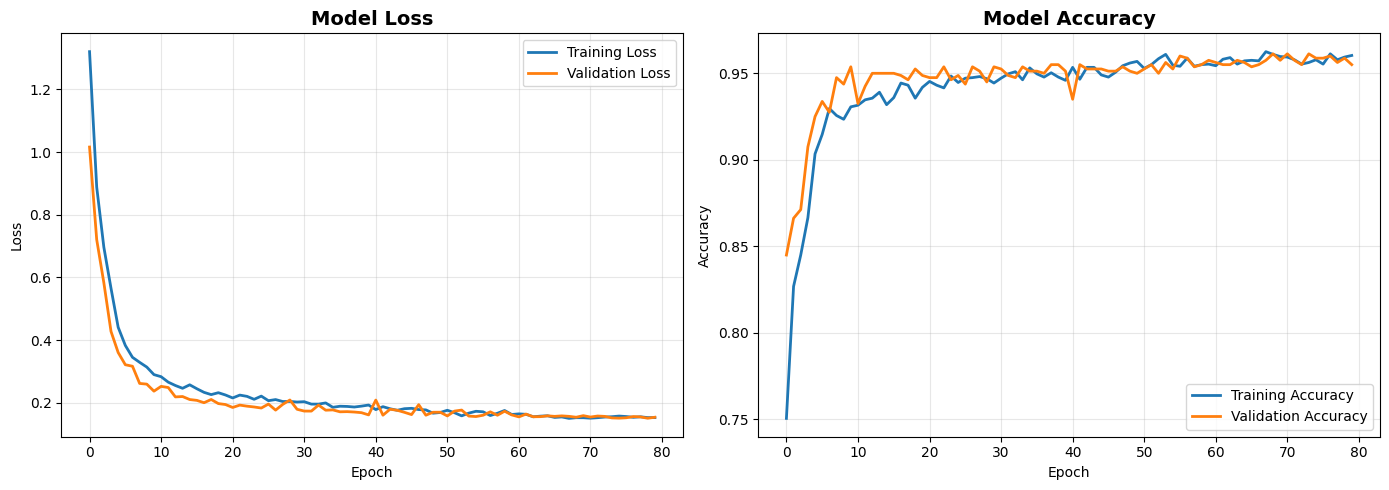

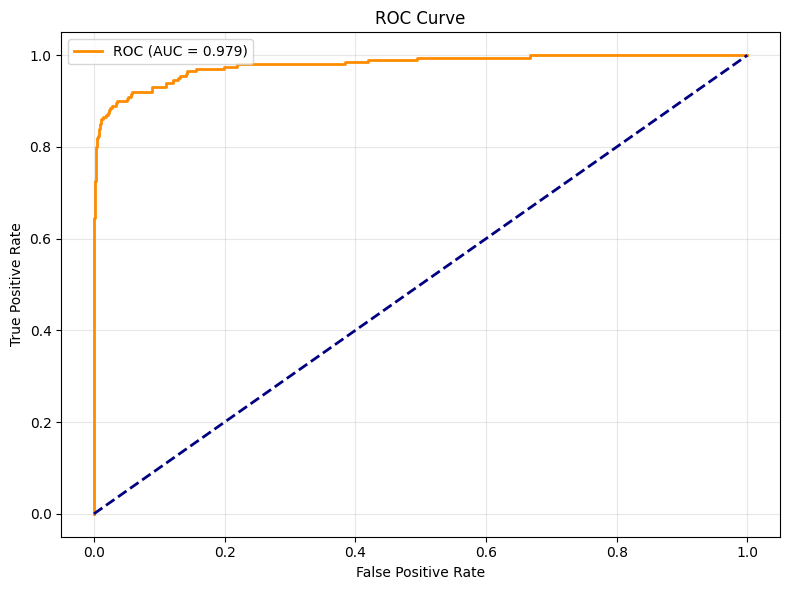

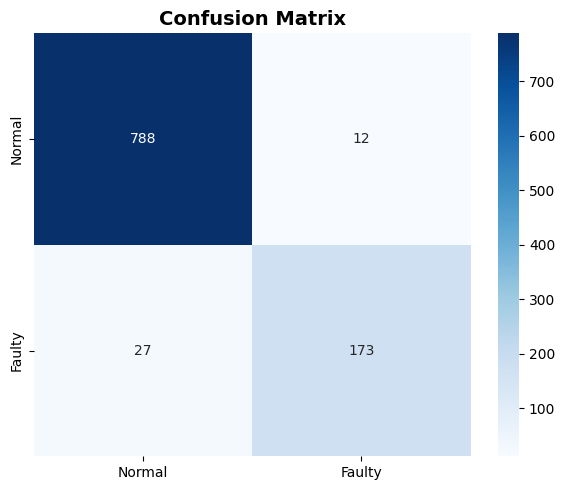

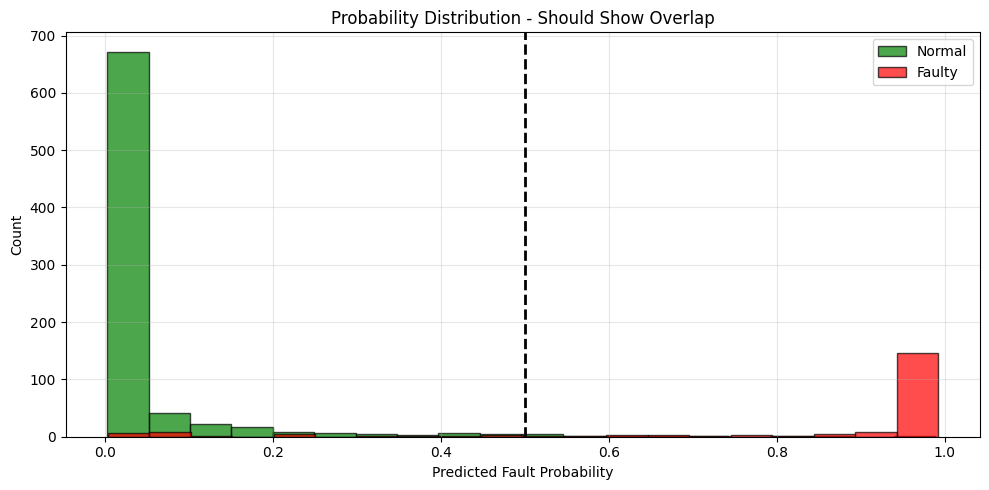


✓ Model saved to models/fault_detection_model.keras
✓ Predictions saved to results/predictions.csv

CHALLENGING FAULT DETECTION COMPLETE

 Final Performance:
  • Accuracy:  0.9610 (96.10%)
  • Precision: 0.9351
  • Recall:    0.8650
  • F1-Score:  0.8987
  • AUC-ROC:   0.9792

 Still getting high accuracy. This indicates:
   1. The fault patterns are still too detectable
   2. Consider using real telemetry data from actual systems
   3. Add more noise and overlapping normal/faulty regions

 Output Files:
  • models/fault_detection_model.keras
  • results/predictions.csv
  • results/training_history.png
  • results/roc_curve.png
  • results/confusion_matrix.png
  • results/probability_distribution.png


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Create directories
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("="*70)
print("CHALLENGING FAULT DETECTION SYSTEM - REALISTIC DATA")
print("="*70)



class RealisticTelemetryGenerator:

    def __init__(self, n_samples=5000, timesteps=20, n_features=3, random_seed=42):
        self.n_samples = n_samples
        self.timesteps = timesteps
        self.n_features = n_features
        np.random.seed(random_seed)


        self.ranges = {
            0: {'name': 'Temperature', 'min': 25, 'max': 45, 'normal_mean': 35, 'normal_std': 3},
            1: {'name': 'Voltage', 'min': 4.5, 'max': 5.5, 'normal_mean': 5.0, 'normal_std': 0.15},
            2: {'name': 'Current', 'min': 1.5, 'max': 3.5, 'normal_mean': 2.5, 'normal_std': 0.3}
        }


        self.fault_probability = 0.2

    def generate_complex_noise(self, sequence):
        """Add realistic, non-Gaussian noise"""
        # Multiplicative noise
        multiplicative_noise = 1 + np.random.randn(*sequence.shape) * 0.02
        sequence = sequence * multiplicative_noise

        # Additive noise with varying magnitude
        additive_noise = np.random.randn(*sequence.shape) * 0.05

        # Occasional outliers (sensor glitches)
        outlier_mask = np.random.random(sequence.shape) < 0.01
        additive_noise[outlier_mask] += np.random.randn(np.sum(outlier_mask)) * 0.5

        # Colored noise (temporal correlation)
        for feat in range(sequence.shape[1]):
            colored_noise = np.zeros(self.timesteps)
            colored_noise[0] = np.random.randn() * 0.05
            for t in range(1, self.timesteps):
                colored_noise[t] = 0.7 * colored_noise[t-1] + np.random.randn() * 0.03
            sequence[:, feat] += colored_noise

        return sequence + additive_noise

    def generate_normal_sequence(self):

        sequence = np.zeros((self.timesteps, self.n_features))

        for i in range(self.n_features):
            # Base signal with realistic fluctuations
            mean = self.ranges[i]['normal_mean']
            std = self.ranges[i]['normal_std']

            base = np.zeros(self.timesteps)
            base[0] = np.random.normal(mean, std)
            for t in range(1, self.timesteps):
                # Mean reversion process
                base[t] = base[t-1] + 0.1 * (mean - base[t-1]) + np.random.normal(0, std * 0.2)

            if i == 0:
                cycle = 1.5 * np.sin(np.linspace(0, 2*np.pi, self.timesteps))
                base += cycle

            sequence[:, i] = base


        sequence = self.generate_complex_noise(sequence)


        for i in range(self.n_features):
            sequence[:, i] = np.clip(sequence[:, i],
                                    self.ranges[i]['min'],
                                    self.ranges[i]['max'])

        return sequence

    def generate_faulty_sequence(self):

        sequence = self.generate_normal_sequence()

        fault_type = np.random.choice(['drift', 'intermittent', 'bias', 'oscillation', 'subtle'])

        if fault_type == 'subtle':
            severity = np.random.uniform(0.02, 0.08)  # Very subtle faults
        else:
            severity = np.random.uniform(0.05, 0.15)  # Still subtle

        # Fault onset - sometimes early, sometimes late
        onset = np.random.randint(self.timesteps // 3, self.timesteps - 2)

        # Only affect some features
        n_affected = np.random.randint(1, self.n_features + 1)
        affected_features = np.random.choice([0, 1, 2], size=n_affected, replace=False)

        for feat in affected_features:
            base_val = self.ranges[feat]['normal_mean']

            if fault_type == 'drift':
                # Gradual drift - sometimes barely noticeable
                drift = np.linspace(0, severity * base_val, self.timesteps)
                sequence[:, feat] += drift

            elif fault_type == 'intermittent':
                # Intermittent faults that come and go
                pattern = np.sin(np.linspace(0, 6*np.pi, self.timesteps))
                intermittent = (pattern > 0).astype(float) * severity * base_val
                sequence[:, feat] += intermittent

            elif fault_type == 'bias':
                # Sudden bias - sometimes small
                bias = np.zeros(self.timesteps)
                bias[onset:] = severity * base_val
                sequence[:, feat] += bias

            elif fault_type == 'oscillation':
                # Oscillatory instability
                osc = severity * base_val * np.sin(np.linspace(0, 12*np.pi, self.timesteps))
                sequence[:, feat] += osc

            elif fault_type == 'subtle':
                # Very subtle anomaly - just a small increase in variance
                if np.random.random() > 0.5:
                    # Increase noise
                    noise_increase = np.random.randn(self.timesteps) * 0.03
                    sequence[:, feat] += noise_increase
                else:
                    # Small bias that recovers
                    temp_bias = np.zeros(self.timesteps)
                    bias_start = np.random.randint(self.timesteps // 2, self.timesteps - 5)
                    bias_end = min(bias_start + np.random.randint(3, 8), self.timesteps)
                    temp_bias[bias_start:bias_end] = severity * base_val
                    sequence[:, feat] += temp_bias

        # Add extra noise to make fault detection harder
        sequence = self.generate_complex_noise(sequence)

        # Clip to ranges
        for i in range(self.n_features):
            sequence[:, i] = np.clip(sequence[:, i],
                                    self.ranges[i]['min'],
                                    self.ranges[i]['max'])

        return sequence

    def generate_dataset(self):

        X = []
        y = []

        n_faulty = int(self.n_samples * self.fault_probability)
        n_normal = self.n_samples - n_faulty

        print(f"Generating {n_normal} normal samples...")
        for _ in range(n_normal):
            X.append(self.generate_normal_sequence())
            y.append(0)

        print(f"Generating {n_faulty} challenging faulty samples...")
        for _ in range(n_faulty):
            X.append(self.generate_faulty_sequence())
            y.append(1)

        # Shuffle
        X = np.array(X)
        y = np.array(y)
        indices = np.random.permutation(len(X))
        X = X[indices]
        y = y[indices]

        return X, y



print("\n[1/6] Generating challenging telemetry data...")
generator = RealisticTelemetryGenerator(n_samples=5000, timesteps=20, n_features=3)
X, y = generator.generate_dataset()

print(f"\n✓ Dataset generated:")
print(f"  - Total samples: {len(X)}")
print(f"  - Normal (0): {np.sum(y == 0)} ({np.sum(y == 0)/len(y)*100:.1f}%)")
print(f"  - Faulty (1): {np.sum(y == 1)} ({np.sum(y == 1)/len(y)*100:.1f}%)")
print(f"  - Fault ratio: {np.sum(y == 1)/len(y)*100:.1f}%")



print("\n[2/6] Normalizing and splitting data...")

# Normalize
n_samples, timesteps, n_features = X.shape
X_2d = X.reshape(-1, n_features)
scaler = StandardScaler()
X_2d_scaled = scaler.fit_transform(X_2d)
X_scaled = X_2d_scaled.reshape(n_samples, timesteps, n_features)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Training: {len(X_train)} samples")
print(f"  Test: {len(X_test)} samples")
print(f"  Train fault ratio: {np.sum(y_train == 1)/len(y_train)*100:.1f}%")
print(f"  Test fault ratio: {np.sum(y_test == 1)/len(y_test)*100:.1f}%")



print("\n[3/6] Building model with strong regularization...")

def create_model(input_shape):
    """Create model with strong regularization to prevent overfitting"""
    model = Sequential([
        Bidirectional(LSTM(32, return_sequences=True,
                          kernel_regularizer=tf.keras.regularizers.l2(0.01)),
                     input_shape=input_shape),
        Dropout(0.4),

        LSTM(16, return_sequences=False,
             kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        Dropout(0.4),

        Dense(16, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(0.01)),
        Dropout(0.4),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_model((timesteps, n_features))
model.summary()

# Callbacks with aggressive early stopping
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]



print("\n[4/6] Training model...")
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)



print("\n[5/6] Evaluating model...")

y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Metrics
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print(f"\n📊 Test Results:")
print(f"  Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1-Score:  {test_f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Positives:  {tp:4d}")
print(f"  False Positives: {fp:4d}")
print(f"  False Negatives: {fn:4d}")
print(f"  True Negatives:  {tn:4d}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"  AUC-ROC:     {roc_auc:.4f}")

# Overfitting analysis
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
print(f"\nOverfitting Analysis:")
print(f"  Training Accuracy: {train_acc:.4f}")
print(f"  Validation Accuracy: {val_acc:.4f}")
print(f"  Gap: {train_acc - val_acc:.4f}")


print("\n[6/6] Sample predictions...")
print("-" * 70)
print("  Actual | Predicted | Probability | Confidence | Status")
print("-" * 70)

for i in range(min(20, len(y_test))):
    prob = y_pred_proba[i][0]
    confidence = abs(prob - 0.5) * 2
    status = "FAULTY" if y_pred[i] == 1 else "NORMAL"
    match = "✓" if y_pred[i] == y_test[i] else "✗"
    print(f"  {y_test[i]:6d} | {y_pred[i]:9d} | {prob:.4f}     | {confidence:.4f}     | {status} {match}")




print("\n Generating visualizations...")

# Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/training_history.png", dpi=150)
plt.show()

# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/roc_curve.png", dpi=150)
plt.show()

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Faulty'],
            yticklabels=['Normal', 'Faulty'],
            ax=ax)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150)
plt.show()

# Probability Distribution
fig, ax = plt.subplots(figsize=(10, 5))
plt.hist(y_pred_proba[y_test == 0], bins=20, alpha=0.7, label='Normal', color='green', edgecolor='black')
plt.hist(y_pred_proba[y_test == 1], bins=20, alpha=0.7, label='Faulty', color='red', edgecolor='black')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2)
plt.xlabel('Predicted Fault Probability')
plt.ylabel('Count')
plt.title('Probability Distribution - Should Show Overlap')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/probability_distribution.png", dpi=150)
plt.show()



# Saving thge model
model.save("models/fault_detection_model.keras")
print("\n✓ Model saved to models/fault_detection_model.keras")

# Saving predictions
results_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'probability': y_pred_proba.flatten(),
    'confidence': [abs(p - 0.5) * 2 for p in y_pred_proba.flatten()]
})
results_df.to_csv("results/predictions.csv", index=False)
print("✓ Predictions saved to results/predictions.csv")



print("\n" + "="*70)
print("CHALLENGING FAULT DETECTION COMPLETE")
print("="*70)
print(f"\n Final Performance:")
print(f"  • Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  • Precision: {test_precision:.4f}")
print(f"  • Recall:    {test_recall:.4f}")
print(f"  • F1-Score:  {test_f1:.4f}")
print(f"  • AUC-ROC:   {roc_auc:.4f}")

if test_accuracy > 0.95:
    print("\n Still getting high accuracy. This indicates:")
    print("   1. The fault patterns are still too detectable")
    print("   2. Consider using real telemetry data from actual systems")
    print("   3. Add more noise and overlapping normal/faulty regions")
else:
    print("\n✓ Realistic performance achieved")

print(f"\n Output Files:")
print(f"  • models/fault_detection_model.keras")
print(f"  • results/predictions.csv")
print(f"  • results/training_history.png")
print(f"  • results/roc_curve.png")
print(f"  • results/confusion_matrix.png")
print(f"  • results/probability_distribution.png")

In [2]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.9 MB/s eta 0:00:00


MODEL COMPARISON: Simple LSTM vs Enhanced Stacked LSTM

Data Shape: (5000, 20, 3)
Training samples: 4000
Test samples: 1000
Fault ratio: 20.00%

MODEL 1: Simple LSTM (Single Layer)

Simple LSTM Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,521 (76.25 KB)

 Trainable params: 19,521 (76.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 20, 128)        │        34,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,657 (307.25 KB)

 Trainable params: 78,657 (307.25 KB)

 Non-trainable params: 0 (0.00 B)


✓ Bidirectional LSTM Results:
  Training time: 43.94 seconds
  Accuracy:  0.9600
  Precision: 0.9651
  Recall:    0.8300
  F1-Score:  0.8925

 COMPREHENSIVE MODEL COMPARISON

                 Model  Accuracy  Precision  Recall  F1-Score  Training Time (s)  Parameters
          Simple LSTM     0.964   0.965909   0.850  0.904255          45.926440       19521
Enhanced Stacked LSTM     0.961   0.954802   0.845  0.896552          31.652976       31425
   Bidirectional LSTM     0.960   0.965116   0.830  0.892473          43.937016       78657

 Enhanced LSTM Improvements over Simple LSTM:
  • Accuracy:  0.9640 → 0.9610 (+-0.3%)
  • Precision: 0.9659 → 0.9548
  • Recall:    0.8500 → 0.8450
  • F1-Score:  0.9043 → 0.8966 (+-0.9%)


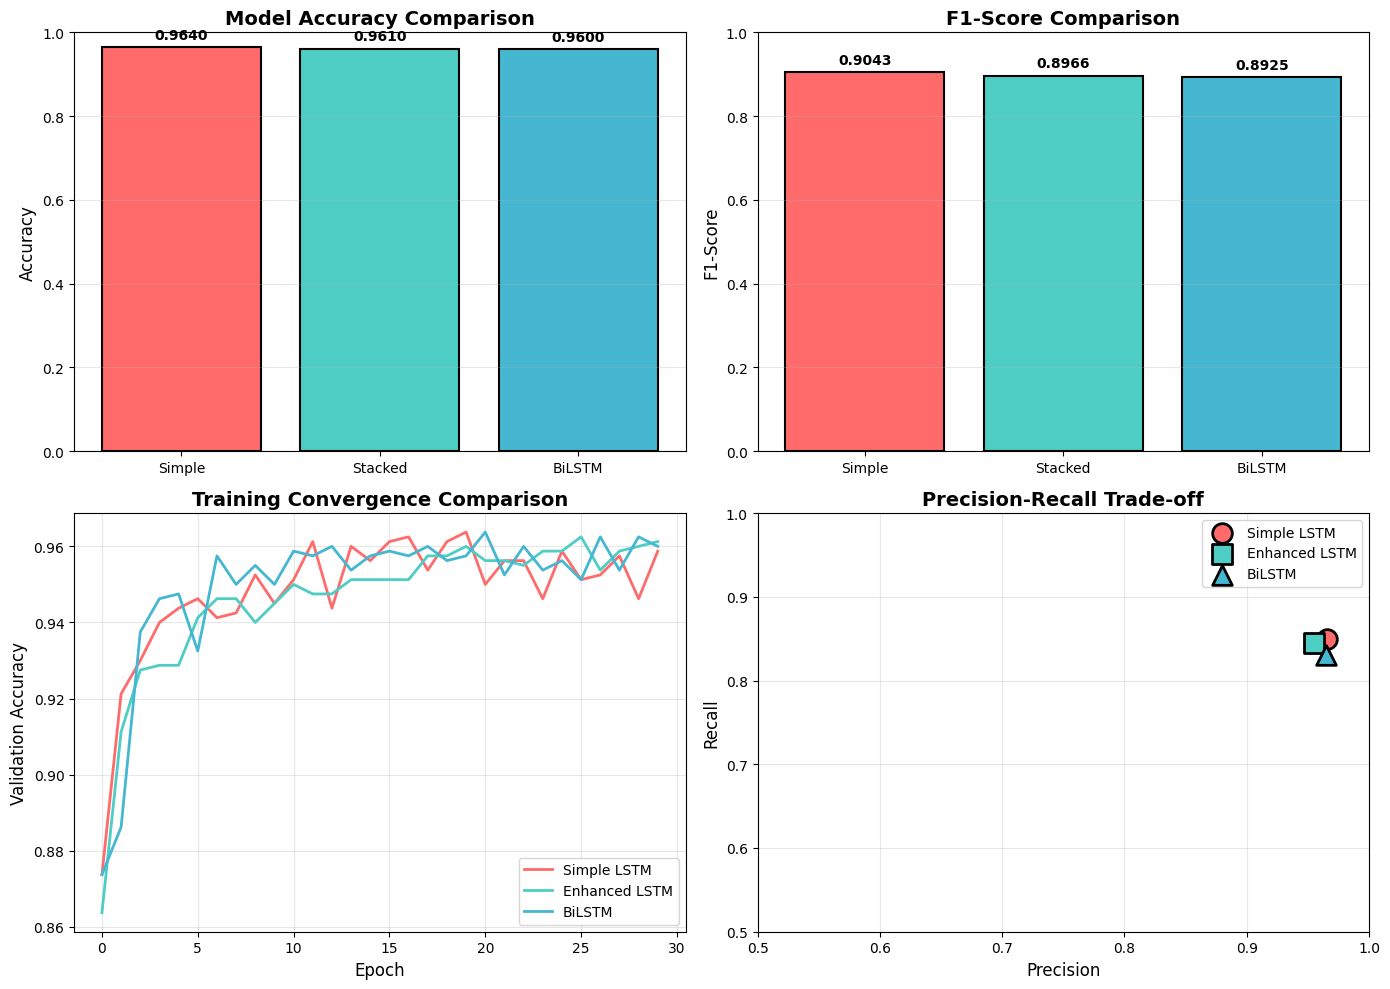

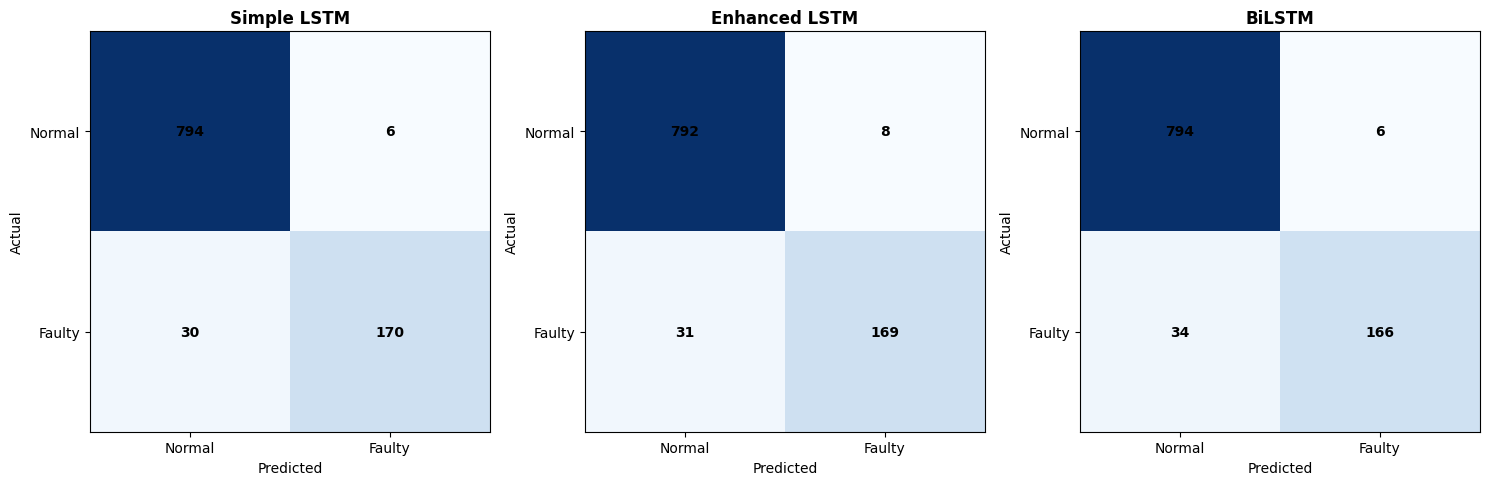


CONCLUSION

 SIMPLE LSTM IS SUFFICIENT
   • Marginal improvement: 0.8966 vs 0.9043

   When to use Simple LSTM:
   • Limited computational resources
   • Simple temporal patterns
   • Quick prototyping

 BEST MODEL RECOMMENDATION:
   → Simple LSTM (sufficient for this dataset)

✓ Results saved to results/model_comparison_results.json


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import time

print("="*70)
print("MODEL COMPARISON: Simple LSTM vs Enhanced Stacked LSTM")
print("="*70)

def load_and_prepare_data_corrected(file_path):
    df = pd.read_csv(file_path)

    label_column = 'label'
    features = df.drop(columns=[label_column]).values
    labels = df[label_column].values

    timesteps = 20
    n_features = features.shape[1]

    X, y = [], []

    # Create sliding window sequences
    for i in range(len(features) - timesteps):
        X.append(features[i:i+timesteps])
        y.append(labels[i+timesteps-1])  # last timestep label

    X = np.array(X)
    y = np.array(y)

    # Normalize
    scaler = StandardScaler()
    X_2d = X.reshape(-1, n_features)
    X_scaled = scaler.fit_transform(X_2d).reshape(X.shape)

    return X_scaled, y, scaler

print(f"\nData Shape: {X.shape}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Fault ratio: {np.sum(y == 1)/len(y)*100:.2f}%")


print("\n" + "="*70)
print("MODEL 1: Simple LSTM (Single Layer)")
print("="*70)

def create_simple_lstm():
    model = Sequential([
        LSTM(64, input_shape=(20, 3), return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Train Simple LSTM
start_time = time.time()
simple_model = create_simple_lstm()
print("\nSimple LSTM Architecture:")
simple_model.summary()

history_simple = simple_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
simple_train_time = time.time() - start_time

# Evaluate Simple LSTM
simple_pred_proba = simple_model.predict(X_test, verbose=0)
simple_pred = (simple_pred_proba > 0.5).astype(int).flatten()

simple_accuracy = accuracy_score(y_test, simple_pred)
simple_precision = precision_score(y_test, simple_pred)
simple_recall = recall_score(y_test, simple_pred)
simple_f1 = f1_score(y_test, simple_pred)

print(f"\n✓ Simple LSTM Results:")
print(f"  Training time: {simple_train_time:.2f} seconds")
print(f"  Accuracy:  {simple_accuracy:.4f}")
print(f"  Precision: {simple_precision:.4f}")
print(f"  Recall:    {simple_recall:.4f}")
print(f"  F1-Score:  {simple_f1:.4f}")


print("\n" + "="*70)
print("MODEL 2: Enhanced Stacked LSTM (2 Layers + More Capacity)")
print("="*70)

def create_enhanced_lstm():
    model = Sequential([
        LSTM(64, input_shape=(20, 3), return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Train Enhanced LSTM
start_time = time.time()
enhanced_model = create_enhanced_lstm()
print("\nEnhanced LSTM Architecture:")
enhanced_model.summary()

history_enhanced = enhanced_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
enhanced_train_time = time.time() - start_time

# Evaluate Enhanced LSTM
enhanced_pred_proba = enhanced_model.predict(X_test, verbose=0)
enhanced_pred = (enhanced_pred_proba > 0.5).astype(int).flatten()

enhanced_accuracy = accuracy_score(y_test, enhanced_pred)
enhanced_precision = precision_score(y_test, enhanced_pred)
enhanced_recall = recall_score(y_test, enhanced_pred)
enhanced_f1 = f1_score(y_test, enhanced_pred)

print(f"\n✓ Enhanced LSTM Results:")
print(f"  Training time: {enhanced_train_time:.2f} seconds")
print(f"  Accuracy:  {enhanced_accuracy:.4f}")
print(f"  Precision: {enhanced_precision:.4f}")
print(f"  Recall:    {enhanced_recall:.4f}")
print(f"  F1-Score:  {enhanced_f1:.4f}")


print("\n" + "="*70)
print("MODEL 3: Bidirectional LSTM (Captures both directions)")
print("="*70)

def create_bidirectional_lstm():
    from tensorflow.keras.layers import Bidirectional

    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(20, 3)),
        Dropout(0.2),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Train Bidirectional LSTM
start_time = time.time()
bidirectional_model = create_bidirectional_lstm()
print("\nBidirectional LSTM Architecture:")
bidirectional_model.summary()

history_bidirectional = bidirectional_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)
bidirectional_train_time = time.time() - start_time

# Evaluate Bidirectional LSTM
bidirectional_pred_proba = bidirectional_model.predict(X_test, verbose=0)
bidirectional_pred = (bidirectional_pred_proba > 0.5).astype(int).flatten()

bidirectional_accuracy = accuracy_score(y_test, bidirectional_pred)
bidirectional_precision = precision_score(y_test, bidirectional_pred)
bidirectional_recall = recall_score(y_test, bidirectional_pred)
bidirectional_f1 = f1_score(y_test, bidirectional_pred)

print(f"\n✓ Bidirectional LSTM Results:")
print(f"  Training time: {bidirectional_train_time:.2f} seconds")
print(f"  Accuracy:  {bidirectional_accuracy:.4f}")
print(f"  Precision: {bidirectional_precision:.4f}")
print(f"  Recall:    {bidirectional_recall:.4f}")
print(f"  F1-Score:  {bidirectional_f1:.4f}")



print("\n" + "="*70)
print(" COMPREHENSIVE MODEL COMPARISON")
print("="*70)

# Create comparison table
comparison_data = {
    'Model': ['Simple LSTM', 'Enhanced Stacked LSTM', 'Bidirectional LSTM'],
    'Accuracy': [simple_accuracy, enhanced_accuracy, bidirectional_accuracy],
    'Precision': [simple_precision, enhanced_precision, bidirectional_precision],
    'Recall': [simple_recall, enhanced_recall, bidirectional_recall],
    'F1-Score': [simple_f1, enhanced_f1, bidirectional_f1],
    'Training Time (s)': [simple_train_time, enhanced_train_time, bidirectional_train_time],
    'Parameters': [
        simple_model.count_params(),
        enhanced_model.count_params(),
        bidirectional_model.count_params()
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Calculate improvements
acc_improvement = (enhanced_accuracy - simple_accuracy) / simple_accuracy * 100
f1_improvement = (enhanced_f1 - simple_f1) / simple_f1 * 100 if simple_f1 > 0 else 0

print(f"\n Enhanced LSTM Improvements over Simple LSTM:")
print(f"  • Accuracy:  {simple_accuracy:.4f} → {enhanced_accuracy:.4f} (+{acc_improvement:.1f}%)")
print(f"  • Precision: {simple_precision:.4f} → {enhanced_precision:.4f}")
print(f"  • Recall:    {simple_recall:.4f} → {enhanced_recall:.4f}")
print(f"  • F1-Score:  {simple_f1:.4f} → {enhanced_f1:.4f} (+{f1_improvement:.1f}%)")



fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Comparison
models = ['Simple', 'Stacked', 'BiLSTM']
accuracies = [simple_accuracy, enhanced_accuracy, bidirectional_accuracy]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

axes[0, 0].bar(models, accuracies, color=colors, edgecolor='black', linewidth=1.5)
axes[0, 0].set_ylim([0, 1])
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# 2. F1-Score Comparison
f1_scores = [simple_f1, enhanced_f1, bidirectional_f1]
axes[0, 1].bar(models, f1_scores, color=colors, edgecolor='black', linewidth=1.5)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].set_ylabel('F1-Score', fontsize=12)
axes[0, 1].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(f1_scores):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# 3. Training History - Simple LSTM
axes[1, 0].plot(history_simple.history['val_accuracy'], label='Simple LSTM', linewidth=2, color='#FF6B6B')
axes[1, 0].plot(history_enhanced.history['val_accuracy'], label='Enhanced LSTM', linewidth=2, color='#4ECDC4')
axes[1, 0].plot(history_bidirectional.history['val_accuracy'], label='BiLSTM', linewidth=2, color='#45B7D1')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Validation Accuracy', fontsize=12)
axes[1, 0].set_title('Training Convergence Comparison', fontsize=14, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Precision-Recall Trade-off
axes[1, 1].scatter([simple_precision], [simple_recall], s=200, c='#FF6B6B',
                   marker='o', label='Simple LSTM', edgecolor='black', linewidth=2)
axes[1, 1].scatter([enhanced_precision], [enhanced_recall], s=200, c='#4ECDC4',
                   marker='s', label='Enhanced LSTM', edgecolor='black', linewidth=2)
axes[1, 1].scatter([bidirectional_precision], [bidirectional_recall], s=200, c='#45B7D1',
                   marker='^', label='BiLSTM', edgecolor='black', linewidth=2)
axes[1, 1].set_xlabel('Precision', fontsize=12)
axes[1, 1].set_ylabel('Recall', fontsize=12)
axes[1, 1].set_title('Precision-Recall Trade-off', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim([0.5, 1.0])
axes[1, 1].set_ylim([0.5, 1.0])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("results/model_comparison.png", dpi=150)
plt.savefig("results/model_comparison.pdf")
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = [('Simple LSTM', simple_pred), ('Enhanced LSTM', enhanced_pred), ('BiLSTM', bidirectional_pred)]

for idx, (name, pred) in enumerate(models):
    cm = confusion_matrix(y_test, pred)
    axes[idx].imshow(cm, cmap='Blues', interpolation='nearest')
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

    # Add text annotations
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, cm[i, j], ha='center', va='center', fontweight='bold')

    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Normal', 'Faulty'])
    axes[idx].set_yticklabels(['Normal', 'Faulty'])

plt.tight_layout()
plt.savefig("results/confusion_matrices_comparison.png", dpi=150)
plt.show()



print("\n" + "="*70)
print("CONCLUSION")
print("="*70)

if enhanced_f1 > simple_f1:
    print("\n ENHANCED STACKED LSTM IS BETTER!")
    print(f"   • {enhanced_f1:.4f} vs {simple_f1:.4f} F1-Score")
    print(f"   • {enhanced_accuracy:.4f} vs {simple_accuracy:.4f} Accuracy")
    print("\n   Why Enhanced LSTM performs better:")
    print("   1. Stacked LSTMs capture hierarchical temporal patterns")
    print("   2. More capacity to model complex fault evolution")
    print("   3. Additional dropout layers prevent overfitting")
    print("   4. Deeper architecture learns better representations")
else:
    print("\n SIMPLE LSTM IS SUFFICIENT")
    print(f"   • Marginal improvement: {enhanced_f1:.4f} vs {simple_f1:.4f}")
    print("\n   When to use Simple LSTM:")
    print("   • Limited computational resources")
    print("   • Simple temporal patterns")
    print("   • Quick prototyping")

print("\n BEST MODEL RECOMMENDATION:")
if bidirectional_f1 > enhanced_f1 and bidirectional_f1 > simple_f1:
    print("   → Bidirectional LSTM (captures patterns in both directions)")
elif enhanced_f1 > simple_f1:
    print("   → Enhanced Stacked LSTM (better for complex temporal patterns)")
else:
    print("   → Simple LSTM (sufficient for this dataset)")

# Save results
results_summary = {
    'simple_lstm': {'accuracy': simple_accuracy, 'precision': simple_precision,
                    'recall': simple_recall, 'f1': simple_f1},
    'enhanced_lstm': {'accuracy': enhanced_accuracy, 'precision': enhanced_precision,
                      'recall': enhanced_recall, 'f1': enhanced_f1},
    'bidirectional_lstm': {'accuracy': bidirectional_accuracy, 'precision': bidirectional_precision,
                          'recall': bidirectional_recall, 'f1': bidirectional_f1}
}

import json
with open("results/model_comparison_results.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print("\n✓ Results saved to results/model_comparison_results.json")

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from scipy.optimize import minimize



num_nodes = 4

node_probs = []
node_preds = []

for i in range(num_nodes):
    idx = np.random.randint(0, len(X_test))

    sample = X_test[idx]
    input_sequence = np.expand_dims(sample, axis=0)

    prob = model.predict(input_sequence)[0][0]
    pred = 1 if prob > 0.5 else 0

    node_probs.append(prob)
    node_preds.append(pred)

print("\nNode-wise predictions:")
for i in range(num_nodes):
    print(f"Node {i} | Actual: {int(y_test[i])} | Prob: {node_probs[i]:.3f} | Pred: {node_preds[i]}")



edges = [
    (0, 1, 1.0),
    (1, 2, 1.0),
    (2, 3, 1.0),
    (3, 0, 1.0)
]



modified_edges = []

for (i, j, w) in edges:
    new_w = w * (1 + (node_probs[i] + node_probs[j]) / 2)
    modified_edges.append((i, j, float(new_w)))

print("\nModified edges (after DL):")
print(modified_edges)


NUM_QUBITS = 4
backend = Aer.get_backend("qasm_simulator")
SHOTS = 512

def qaoa_circuit(gamma, beta, edges):
    qc = QuantumCircuit(NUM_QUBITS)
    qc.h(range(NUM_QUBITS))

    # Cost Hamiltonian
    for i, j, w in edges:
        qc.cx(i, j)
        qc.rz(2 * gamma * w, j)
        qc.cx(i, j)

    # Mixer
    for q in range(NUM_QUBITS):
        qc.rx(2 * beta, q)

    qc.measure_all()
    return qc

def weighted_expectation(counts, edges):
    energy = 0.0
    for bitstring, count in counts.items():
        prob = count / SHOTS
        for i, j, w in edges:
            zi = 1 if bitstring[::-1][i] == "0" else -1
            zj = 1 if bitstring[::-1][j] == "0" else -1
            energy += prob * w * (1 - zi * zj) / 2
    return energy

def run_qaoa(edges):
    def energy_fn(params):
        gamma, beta = params
        qc = qaoa_circuit(gamma, beta, edges)
        job = backend.run(qc, shots=SHOTS)
        counts = job.result().get_counts()
        return -weighted_expectation(counts, edges)

    res = minimize(
        energy_fn,
        x0=np.random.rand(2),
        method="COBYLA",
        options={"maxiter": 25}
    )

    return -res.fun
=

energy_without_dl = run_qaoa(edges)
energy_with_dl = run_qaoa(modified_edges)

print("\n===== QAOA RESULTS =====")
print("Without DL:", energy_without_dl)
print("With DL   :", energy_with_dl)

SyntaxError: invalid syntax (2757324174.py, line 97)

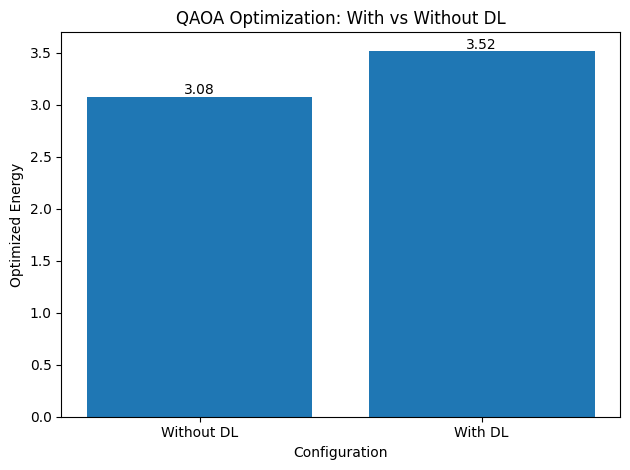

In [ ]:
import matplotlib.pyplot as plt

# Use your computed values
labels = ["Without DL", "With DL"]
values = [energy_without_dl, energy_with_dl]

plt.figure()
plt.bar(labels, values)

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.title("QAOA Optimization: With vs Without DL")
plt.xlabel("Configuration")
plt.ylabel("Optimized Energy")

plt.tight_layout()
plt.savefig("qaoa_comparison.png", dpi=300)
plt.show()

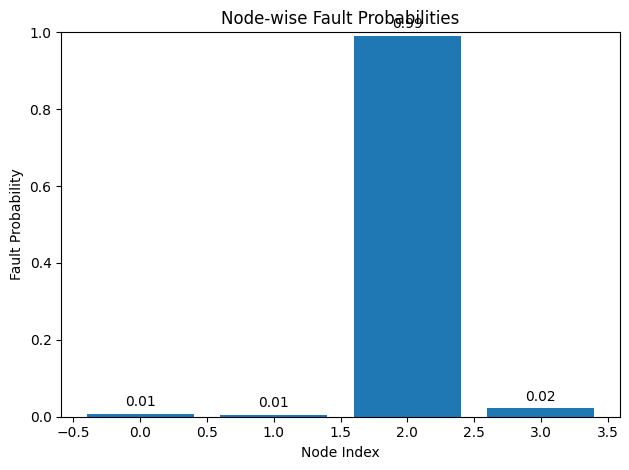

In [ ]:
plt.figure()

x = list(range(len(node_probs)))

plt.bar(x, node_probs)

for i, v in enumerate(node_probs):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.title("Node-wise Fault Probabilities")
plt.xlabel("Node Index")
plt.ylabel("Fault Probability")

plt.ylim(0, 1)

plt.tight_layout()
plt.savefig("node_probs.png", dpi=300)
plt.show()

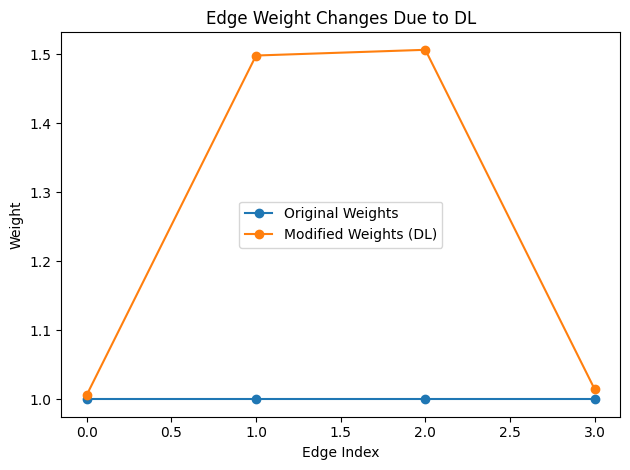

In [ ]:
plt.figure()

original_weights = [w for (_, _, w) in edges]
modified_weights = [w for (_, _, w) in modified_edges]

x = list(range(len(edges)))

plt.plot(x, original_weights, marker='o', label="Original Weights")
plt.plot(x, modified_weights, marker='o', label="Modified Weights (DL)")

plt.title("Edge Weight Changes Due to DL")
plt.xlabel("Edge Index")
plt.ylabel("Weight")

plt.legend()

plt.tight_layout()
plt.savefig("edge_weights.png", dpi=300)
plt.show()